In [1]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted
from skimage import io as io_skimage
import os

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

2025-11-04 15:23:30,940 [INFO] WRITING LOG OUTPUT TO C:\Users\sthem\.cellpose\run.log
2025-11-04 15:23:30,940 [INFO] 
cellpose version: 	4.0.8.dev11+g70c0d07d0 
platform:       	win32 
python version: 	3.10.16 
torch version:  	2.5.1
2025-11-04 15:23:31,041 [INFO] ** TORCH CUDA version installed and working. **
2025-11-04 15:23:31,042 [INFO] ** TORCH CUDA version installed and working. **
2025-11-04 15:23:31,043 [INFO] >>>> using GPU (CUDA)
2025-11-04 15:23:32,494 [INFO] >>>> loading model C:\Users\sthem\.cellpose\models\cpsam


In [2]:
dir_train = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train"
dir_train = Path(dir_train)

dir_val = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\val"
dir_val = Path(dir_val)

dir_out_train = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_masks\train_masks"
dir_out_train = Path(dir_out_train)

dir_out_val = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_masks\val_masks"
dir_out_val = Path(dir_out_val)

In [3]:
def list_files(directory, extension = ".bmp"):
    if not directory.exists():
        raise FileNotFoundError("directory does not exist")

    # *** change to your image extension ***
    image_ext = extension

    # list all files
    files = natsorted([f for f in directory.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])

    if(len(files)==0):
        raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
    else:
        print(f"{len(files)} images in folder:")

    for f in files:
        print(f.name)


In [4]:
files_dir_train = list_files(dir_train, extension = ".bmp")
files_dir_train

221 images in folder:
2022_03_21_11_02_58_05.bmp
2022_03_21_11_02_58_14.bmp
2022_03_21_11_02_58_22.bmp
2022_03_21_11_02_58_31.bmp
2022_03_21_11_02_58_39.bmp
2022_03_21_11_02_58_47.bmp
2022_03_21_11_02_58_56.bmp
2022_03_21_11_02_58_64.bmp
2022_03_21_11_02_58_72.bmp
2022_03_21_11_02_58_89.bmp
2022_03_21_11_02_58_98.bmp
2022_03_21_11_02_59_14.bmp
2022_03_21_11_02_59_23.bmp
2022_03_21_11_02_59_32.bmp
2022_03_21_11_02_59_40.bmp
2022_03_21_11_02_59_48.bmp
2022_03_21_11_02_59_57.bmp
2022_03_21_11_02_59_65.bmp
2022_03_21_11_02_59_73.bmp
2022_03_21_11_02_59_82.bmp
2022_03_21_11_02_59_90.bmp
2022_03_21_11_02_59_98.bmp
2022_03_21_11_03_00_36.bmp
2022_03_21_11_03_00_42.bmp
2022_03_21_11_03_00_49.bmp
2022_03_21_11_03_00_57.bmp
2022_03_21_11_03_00_65.bmp
2022_03_21_11_03_00_73.bmp
2022_03_21_11_03_00_82.bmp
2022_03_21_11_03_00_90.bmp
2022_03_21_11_03_00_98.bmp
2022_03_21_11_03_01_07.bmp
2022_03_21_11_03_01_15.bmp
2022_03_21_11_03_01_23.bmp
2022_03_21_11_03_01_32.bmp
2022_03_21_11_03_01_40.bmp
2022_0

In [5]:
files_dir_val = list_files(dir_val, extension = ".bmp")
files_dir_val

221 images in folder:
2022_03_21_11_05_09_12.bmp
2022_03_21_11_05_10_79.bmp
2022_03_21_11_05_14_14.bmp
2022_03_21_11_05_15_81.bmp
2022_03_21_11_05_17_48.bmp
2022_03_21_11_05_19_16.bmp
2022_03_21_11_05_20_83.bmp
2022_03_21_11_05_22_50.bmp
2022_03_21_11_05_24_18.bmp
2022_03_21_11_05_25_85.bmp
2022_03_21_11_05_29_20.bmp
2022_03_21_11_05_30_88.bmp
2022_03_21_11_05_32_54.bmp
2022_03_21_11_05_34_22.bmp
2022_03_21_11_05_39_25.bmp
2022_03_21_11_05_40_91.bmp
2022_03_21_11_05_42_59.bmp
2022_03_21_11_05_44_27.bmp
2022_03_21_11_05_45_94.bmp
2022_03_21_11_05_47_61.bmp
2022_03_21_11_05_49_29.bmp
2022_03_21_11_05_50_96.bmp
2022_03_21_11_05_52_63.bmp
2022_03_21_11_05_54_30.bmp
2022_03_21_11_05_55_98.bmp
2022_03_21_11_05_57_65.bmp
2022_03_21_11_05_59_33.bmp
2022_03_21_11_06_07_70.bmp
2022_03_21_11_06_09_37.bmp
2022_03_21_11_06_11_04.bmp
2022_03_21_11_06_12_72.bmp
2022_03_21_11_06_16_07.bmp
2022_03_21_11_06_17_74.bmp
2022_03_21_11_06_19_41.bmp
2022_03_21_11_06_21_09.bmp
2022_03_21_11_06_22_76.bmp
2022_0

In [6]:
def checking_shape(files):
    # dir_train = caminho da pasta (por exemplo, '/content/drive/MyDrive/malaria/train')
    files_dir = [f for f in os.listdir(files) if f.endswith(".bmp")]

    file_path = os.path.join(files, files_dir[0])
    print("Abrindo:", file_path)

    img = io_skimage.imread(file_path)
    print(f"Sua imagem tem shape: {img.shape}")

In [7]:
checking_shape(dir_train)



Abrindo: C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train\2022_03_21_11_02_58_05.bmp
Sua imagem tem shape: (1088, 2048)


In [8]:
checking_shape(dir_val)

Abrindo: C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\val\2022_03_21_11_05_09_12.bmp
Sua imagem tem shape: (1088, 2048)


In [9]:
first_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = '1' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = '2' # @param ['None', 0, 1, 2, 3, 4, 5]

In [10]:
# constrói lista de canais pedidos (ex: [0,1], etc)
def checking_images(files, first_channel='0', second_channel='1', third_channel='2'):
    files_dir = [f for f in os.listdir(files) if f.endswith(".bmp")]

    file_path = os.path.join(files, files_dir[0])

    img = io_skimage.imread(file_path)

    selected_channels = []
    for i, c in enumerate([first_channel, second_channel, third_channel]):
        if c == 'None':
            continue
        if int(c) >= img.shape[-1] and img.ndim == 3:
            assert False, 'invalid channel index, must have index < number of channels'
        if c != 'None':
            selected_channels.append(int(c))

    # Agora criamos img_selected_channels corretamente
    if img.ndim == 2:
        # imagem já é 1 canal, só replica para o formato esperado pelo modelo
        # Cellpose espera (H, W, n_channels)
        img_selected_channels = img[..., np.newaxis]  # vira (H, W, 1)
    else:
        # imagem tem 3 canais, seguimos a lógica original
        img_selected_channels = np.zeros_like(img)
        img_selected_channels[:, :, :len(selected_channels)] = img[:, :, selected_channels]
        

    flow_threshold = 0.4
    cellprob_threshold = 0.0
    tile_norm_blocksize = 0

    masks, flows, styles = model.eval(img_selected_channels, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                    normalize={"tile_norm_blocksize": tile_norm_blocksize})

    fig = plt.figure(figsize=(12,5))
    plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
    plt.tight_layout()
    plt.show()


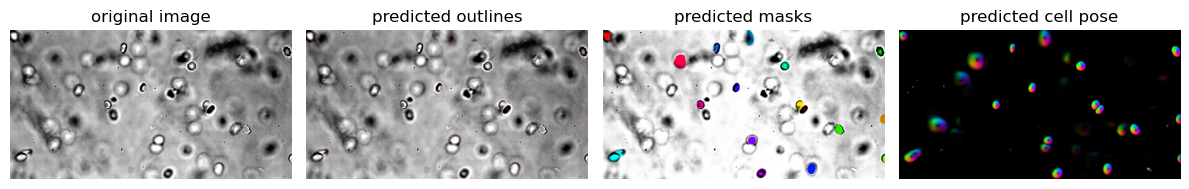

In [11]:
checking_images(dir_train)

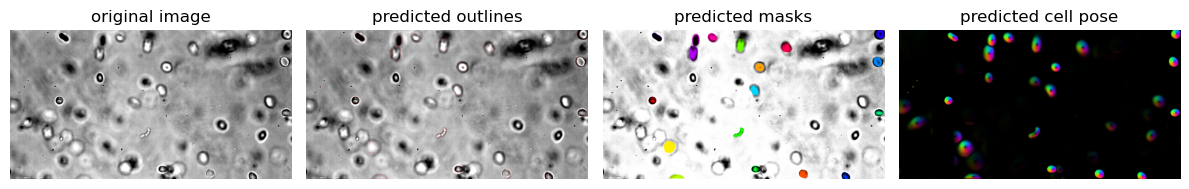

In [15]:
checking_images(dir_val)

#### Caso queira fazer com o giemsa:

Esse código abaixo é o disponibilizado pelo cellpose no github(para 3 canais: H,W,C) - altura, comprimento e cor RBG

```
selected_channels = []
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  if int(c) > img.shape[-1]:
    assert False, 'invalid channel index, must have index greater or equal to the number of channels'
  if c != 'None':
    selected_channels.append(int(c))



img_selected_channels = np.zeros_like(img)
img_selected_channels[:, :, :len(selected_channels)] = img[:, :, selected_channels]


flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

masks, flows, styles = model.eval(img_selected_channels, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
plt.tight_layout()
plt.show()
```

### Salvando as imagens

In [12]:
# masks_ext = ".png"
# for i in trange(len(files)):
#     f = files[i]
#     img = io.imread(f)
#     masks, flows, styles = model.eval(img, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
#                                   normalize={"tile_norm_blocksize": tile_norm_blocksize})
#     io.imsave(dir / (f.stem + "_masks" + masks_ext), masks)

In [13]:
#for i in trange(len(files)):
#    f = files[i]
#    masks0 = io.imsave(dir / (f.name + "_masks" + masks_ext))
#    io.save_rois(masks0, f)

In [18]:
def creating_masks(input_dir, output_dir, model):
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)
    raw_dir = output_dir / "raw"
    viz_dir = output_dir / "viz"

    # Cria as subpastas se não existirem
    raw_dir.mkdir(parents=True, exist_ok=True)
    viz_dir.mkdir(parents=True, exist_ok=True)

    files = list(input_dir.glob("*.bmp"))
    print(f"{len(files)} imagens encontradas em {input_dir}")

    for i in trange(len(files), desc="Gerando máscaras"):
        file_path = files[i]
        img = io_skimage.imread(file_path)

        masks, flows, styles = model.eval(img, batch_size=32)
        base_name = file_path.stem  # nome sem extensão

        # Salva máscara “crua”
        io_skimage.imsave(raw_dir / f"{base_name}_masks_raw.png", masks.astype(np.uint16))

        # Salva versão visual (escala 0–255)
        if masks.max() > 0:
            viz_mask = (masks.astype(np.float32) / masks.max() * 255)
        else:
            viz_mask = masks.astype(np.float32)
        viz_mask = viz_mask.astype(np.uint8)

        io_skimage.imsave(viz_dir / f"{base_name}_masks_viz.png", viz_mask)

In [19]:
creating_masks(
    input_dir=dir_train,
    output_dir=dir_out_train,
    model=model
)

221 imagens encontradas em C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train


Gerando máscaras:   0%|          | 0/221 [00:00<?, ?it/s]c:\Users\sthem\anaconda3\envs\swin_transformer\lib\site-packages\skimage\_shared\utils.py:328: UserWarning: C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_masks\train_masks\raw\2022_03_21_11_02_58_05_masks_raw.png is a low contrast image
  return func(*args, **kwargs)
Gerando máscaras:   0%|          | 1/221 [00:02<09:06,  2.48s/it]c:\Users\sthem\anaconda3\envs\swin_transformer\lib\site-packages\skimage\_shared\utils.py:328: UserWarning: C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_masks\train_masks\raw\2022_03_21_11_02_58_14_masks_raw.png is a low contrast image
  return func(*args, **kwargs)
Gerando máscaras:   1%|          | 2/221 [00:04<08:38,  2.37s/it]c:\Users\sthem\anaconda3\envs\swin_transformer\lib\site-packages\skimage\_shared\utils.py:328: UserWarning: C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_masks\train_masks\

In [20]:
creating_masks(
    input_dir=dir_val,
    output_dir=dir_out_val,
    model=model
)

221 imagens encontradas em C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\val


Gerando máscaras:   0%|          | 0/221 [00:00<?, ?it/s]c:\Users\sthem\anaconda3\envs\swin_transformer\lib\site-packages\skimage\_shared\utils.py:328: UserWarning: C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_masks\val_masks\raw\2022_03_21_11_05_09_12_masks_raw.png is a low contrast image
  return func(*args, **kwargs)
Gerando máscaras:   0%|          | 1/221 [00:02<08:12,  2.24s/it]c:\Users\sthem\anaconda3\envs\swin_transformer\lib\site-packages\skimage\_shared\utils.py:328: UserWarning: C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_masks\val_masks\raw\2022_03_21_11_05_10_79_masks_raw.png is a low contrast image
  return func(*args, **kwargs)
Gerando máscaras:   1%|          | 2/221 [00:04<08:10,  2.24s/it]c:\Users\sthem\anaconda3\envs\swin_transformer\lib\site-packages\skimage\_shared\utils.py:328: UserWarning: C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_masks\val_masks\raw\20